In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [4]:
df.groupby('group')['converted'].mean()

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64

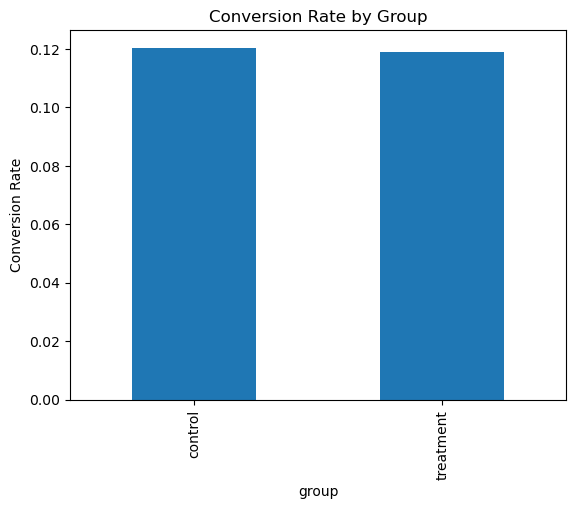

In [5]:
conversion_rates = df.groupby('group')['converted'].mean()

conversion_rates.plot(kind='bar')
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

In [6]:
control = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']

successes = [control.sum(), treatment.sum()]
samples = [len(control), len(treatment)]

z_stat, p_value = proportions_ztest(successes, samples)

print("Z-Statistic:", z_stat)
print("P-Value:", p_value)

Z-Statistic: 1.2369217547321678
P-Value: 0.21611613269757501


In [7]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("New Page performs significantly different.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference between pages.")

Fail to Reject Null Hypothesis
No significant difference between pages.
